### 1.线性分类

#### 导入模块

In [ ]:
from sklearn.datasets import load_iris # load_iris是 sklearn 内置的经典分类数据集加载函数
from sklearn.pipeline import make_pipeline # make_pipeline用于快速构建机器学习流水线，将「数据预处理」和「模型训练 / 预测」步骤按顺序串联
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC # 线性支持向量分类器
from sklearn.model_selection import train_test_split # 主要用于数据的划分与模型的筛选,提供了将原始数据科学地分为训练集（Training Set）和测试集（Test Set）的方法
from sklearn.metrics import accuracy_score, f1_score, classification_report # 实现性能评估
# classification_report: 一个集成工具，能一次性输出所有关键指标的汇总表

#### 数据集加载与预处理

In [98]:
# 加载完整鸢尾花数据集，存入iris变量
# 后续可通过iris.data取特征、iris.target取标签、iris.target_names取花品种名称。
iris = load_iris(as_frame=True) 
''' load_iris() 默认返回的整体是 Bunch 类字典对象,这个 Bunch 对象里的 iris.data 属性是 NumPy 数组(纯特征数据),iris.target 属性也是 NumPy 数组（纯标签数据）
as_frame=True会让特征数据data和标签target以pandas.DataFrame/Series格式返回
load_iris() 默认返回的 iris.data 是 NumPy 数组，而 as_frame=True 会将其转换为 pandas DataFrame'''

X = iris.data[["petal length (cm)", "petal width (cm)"]].values # 加载后的特征 DataFrame，每行是 1 个样本，每列是 1 个特征
''' 注意：双层方括号代表选取多列，返回 DataFrame(单层方括号 + 单个列名会返回 Series)
.values:pandas 的内置属性，将 DataFrame 转换为 numpy 的ndarray数组,符合 sklearn 模型的输入格式要求。'''

y = (iris.target == 2)
''' 原生标签数组，取值为 0、1、2,分别对应setosa、versicolor、virginica三个鸢尾花品种
对标签数组的每个元素逐一判断是否等于 2(即判断是否是第三个品种),等于返回True,不等于返回False,最终生成和标签长度一致的布尔数组
scikit-learn 的所有分类器,fit() 方法都要求传入两个独立的参数：

特征矩阵 X:二维数组,形状 (n_samples, n_features),只包含输入特征;
标签向量 y:一维数组,形状 (n_samples,),只包含真实标签.'''

' 原生标签数组，取值为 0、1、2,分别对应setosa、versicolor、virginica三个鸢尾花品种\n对标签数组的每个元素逐一判断是否等于 2(即判断是否是第三个品种),等于返回True,不等于返回False,最终生成和标签长度一致的布尔数组\nscikit-learn 的所有分类器,fit() 方法都要求传入两个独立的参数：\n\n特征矩阵 X:二维数组,形状 (n_samples, n_features),只包含输入特征;\n标签向量 y:一维数组,形状 (n_samples,),只包含真实标签.'

#### 分割训练集与测试集

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, 
    test_size=0.2, 
    random_state=42,
    stratify=y)
# 需要传入的参数：X: 特征矩阵（输入数据），y: 标签向量（目标结果），测试集比例
''' stratify （分层采样）各分类的比例与原始数据一致，防止测试集里全是某一类样本
当数据集本身类别不平衡 或者样本量较小（随机波动很大），必须采用分层采样'''

#### 模型流水线构建与训练

In [100]:
# 构建流水线对象svm_clf
svm_clf = make_pipeline(StandardScaler(),LinearSVC(C=1,random_state=42)) # 这里传入的是两个实例化对象并设置随机种子
# make_pipeline会自动按传入顺序串联步骤，前一步的输出作为后一步的输入
svm_clf.fit(X_train, y_train)
'''逻辑作用:fit方法会按流水线顺序自动执行完整训练流程
先调用StandardScaler.fit(),用训练集X计算每个特征的均值和标准差,完成标准化器的拟合!!!;
调用StandardScaler.transform(),用拟合好的参数对X做标准化转换,得到标准化后的特征X_scaled;
调用LinearSVC.fit(),用X_scaled和y训练线性 SVM 模型，求解出最优的分类决策边界。'''

'逻辑作用:fit方法会按流水线顺序自动执行完整训练流程\n先调用StandardScaler.fit(),用训练集X计算每个特征的均值和标准差,完成标准化器的拟合!!!;\n调用StandardScaler.transform(),用拟合好的参数对X做标准化转换,得到标准化后的特征X_scaled;\n调用LinearSVC.fit(),用X_scaled和y训练线性 SVM 模型，求解出最优的分类决策边界。'

#### 模型预测与决策函数

In [101]:
# 模型预测
X_new = [[5.5, 1.7], [5.0, 1.5]] # 预测方法要求输入必须是二维结构(n_samples, n_features)
print(svm_clf.predict(X_new))
'''predict方法会自动执行流水线的完整推理流程:
1.用训练时拟合好的StandardScaler,对X_new做标准化转换
2.将标准化后的新样本输入训练好的 LinearSVC 模型，输出预测标签'''

# 决策边界
# 线性 SVM 的决策函数，计算的是样本点到分类决策边界的有符号距离(有正负之分)
print(svm_clf.decision_function(X_new))
# 值 > 0，样本在决策边界的正类一侧，模型预测为True;值 = 0，样本正好落在决策边界上
# 绝对值越大,离边界距离较远,置信度较高

[ True False]
[ 0.66112984 -0.17122279]


#### 预测并查看 ACC 和 F1

In [ ]:
y_pred = svm_clf.predict(X_test)
print("--- LinearSVC 评估结果 ---")
print(f"准确率 (ACC): {accuracy_score(y_test, y_pred):.4f}") # y_test即为测试集里的真实值
print(f"F1 分数: {f1_score(y_test, y_pred):.4f}")

--- LinearSVC 评估结果 ---
准确率 (ACC): 1.0000
F1 分数: 1.0000


### 一些问题:
原文：
> 与LogisticRegression不同，LinearSVC没有predict_proba（）方法来估计类概率。也就是说，如果你使用SVC类（稍后讨论）而不是LinearSVC，并且将其probability超参数设置为True，则该模型将在训练结束时拟合一个额外的模型以把SVM决策函数分数映射到估计的概率。在底层，这需要使用5折交叉验证为训练集中的每个实例生成样本外预测，然后训练LogisticRegression模型，因此它会大大减慢训练速度。之后，predict_proba（）和predict_log_proba（）方法就可用了。

逐句拆解解释：
1.  **与LogisticRegression不同，LinearSVC没有predict_proba()方法来估计类概率**
    - 逻辑核心：Logistic回归的核心原理是通过sigmoid函数，将线性输出映射到0-1区间，天然输出分类概率，因此原生自带`predict_proba()`方法，可直接返回每个类别的预测概率。
    - 而LinearSVC（线性SVM）的核心目标是求解「最大分类间隔的决策边界」，输出的是样本到边界的距离值，而非概率值，因此LinearSVC类本身没有实现`predict_proba()`方法，无法直接输出分类概率。

2.  **如果你使用SVC类而不是LinearSVC，并且将其probability超参数设置为True，则该模型将在训练结束时拟合一个额外的模型以把SVM决策函数分数映射到估计的概率**
    - 补充背景：sklearn中的`SVC`是通用支持向量分类器，支持线性核、多项式核、高斯核等多种核函数，和专门优化线性场景的LinearSVC是两个不同的类。
    - 逻辑解释：SVC类提供了`probability`这个超参数（默认False），当设置为True时，模型会在完成SVM本身的训练后，额外训练一个校准模型，把SVM决策函数输出的距离值，映射为0-1区间的分类概率，这个方法叫做**Platt缩放**，是SVM概率校准的经典方案。

3.  **在底层，这需要使用5折交叉验证为训练集中的每个实例生成样本外预测，然后训练LogisticRegression模型，因此它会大大减慢训练速度**
    - 底层实现逻辑：
      1.  为了避免概率校准模型过拟合，不能用训练SVM的同一批数据训练校准模型，因此需要做5折交叉验证：把训练集分成5份，轮流用4份训练SVM，1份做验证，为每个样本生成「未参与该轮训练的样本外决策值」，保证数据无泄露；
      2.  用交叉验证得到的样本外决策值作为特征，原始标签作为目标，训练一个Logistic回归模型，这个模型的唯一作用就是把SVM的距离值映射为概率。
    - 速度影响：该过程需要额外训练5次SVM+1次Logistic回归，因此会大幅增加训练耗时，这也是`probability`默认关闭的原因。

4.  **之后，predict_proba()和predict_log_proba()方法就可用了**
    - 逻辑解释：当设置`probability=True`并完成SVC模型训练后，就可以正常调用两个概率相关方法：
      - `predict_proba()`：返回每个样本属于各个类别的概率，取值范围0-1，所有类别概率和为1；
      - `predict_log_proba()`：返回概率的对数值，适合需要计算对数似然、交叉熵损失的场景。
    - 补充：LinearSVC本身不支持该功能，若需要用LinearSVC输出概率，需要手动实现Platt缩放，对其decision_function的输出做概率校准。

### 2.非线性分类

#### 模块导入

In [103]:
from sklearn.datasets import make_moons # 专门用于生成月牙形非线性二分类数据集的工具
from sklearn.preprocessing import  PolynomialFeatures# SVM 处理非线性问题的经典 “显式核映射” 方案

#### 非线性数据集生成

In [104]:
X,y = make_moons(n_samples=100,noise=0.15,random_state=42) # 噪声数值越大，数据点越分散，两个月牙的重叠越多，分类难度越大
''' 解包赋值：make_moons默认返回 2 个 numpy 数组，第一个是特征矩阵，第二个是标签向量
特别注意：特征矩阵X：shape 为(100, 2)，标签向量y：shape 为(100,)，一维 numpy 数组'''

' 解包赋值：make_moons默认返回 2 个 numpy 数组，第一个是特征矩阵，第二个是标签向量\n特别注意：特征矩阵X：shape 为(100, 2)，标签向量y：shape 为(100,)，一维 numpy 数组'

#### 流水线构建

In [105]:
# 按顺序串联「特征转换→特征标准化→模型训练」三个步骤，返回的流水线对象赋值给polynomial_svm_clf
polynomial_svm_clf = make_pipeline(
    PolynomialFeatures(degree=3), # 指定多项式的最高次数为 3 次。
    StandardScaler(),
    LinearSVC(C=10,max_iter=10_000,random_state=42) # 映射到 10 维高维空间后，数据就变成线性可分的，于是可以直接使用线性分类器
    )
'''原本的 2 维特征，会被转换成10 维的高维特征矩阵
多项式次数	生成的特征
0 次项（偏置项）	1
1 次项（原始特征）	x1, x2
2 次项	x1², x1x2, x2²
3 次项	x1³, x1²x2, x1x2², x2³'''

'''
经过多项式转换后，不同次数的特征数值范围差异极大
而 SVM 对特征尺度极度敏感，必须对所有特征进行标准化
需要特别注意的是：相较与线性数据集，非线性数据集更复杂，因此需要减弱正则化，
即增大C，使分类错误样本尽可能少，从而让模型能拟合更复杂的分类边界。(当然不能过大，防止过拟合)

SVM 的正则化由超参数 C 控制，C 和正则化强度成反比：
C 越小 → 正则化强度越大：模型会优先 “扩大分类间隔”，容忍训练集中少量样本分类错误，
避免模型过度纠结于训练集的噪声，得到更简单、泛化能力更强的模型。
C 越大 → 正则化强度越小：模型会优先 “把训练集所有样本分类正确”，
甚至会为了个别噪声样本调整分类边界，容易过拟合（在训练集上表现极好，但在新的测试集上表现很差）。
'''

'\n经过多项式转换后，不同次数的特征数值范围差异极大\n而 SVM 对特征尺度极度敏感，必须对所有特征进行标准化\n需要特别注意的是：相较与线性数据集，非线性数据集更复杂，因此需要减弱正则化，\n即增大C，使分类错误样本尽可能少，从而让模型能拟合更复杂的分类边界。(当然不能过大，防止过拟合)\n\nSVM 的正则化由超参数 C 控制，C 和正则化强度成反比：\nC 越小 → 正则化强度越大：模型会优先 “扩大分类间隔”，容忍训练集中少量样本分类错误，\n避免模型过度纠结于训练集的噪声，得到更简单、泛化能力更强的模型。\nC 越大 → 正则化强度越小：模型会优先 “把训练集所有样本分类正确”，\n甚至会为了个别噪声样本调整分类边界，容易过拟合（在训练集上表现极好，但在新的测试集上表现很差）。\n'

#### 模型训练

In [106]:
polynomial_svm_clf.fit(X_train, y_train)
'''
第一步：调用PolynomialFeatures.fit_transform(X)，用原始 X 拟合多项式转换器，同时把 X 转换为 10 维的高维多项式特征矩阵；
第二步：调用StandardScaler.fit_transform(...)，用高维特征拟合标准化器，计算每个特征的均值和标准差，同时完成特征标准化；
第三步：调用LinearSVC.fit(...)，用标准化后的高维特征和标签 y，训练线性 SVM 模型，求解出高维空间中的最优分类超平面。
'''

'\n第一步：调用PolynomialFeatures.fit_transform(X)，用原始 X 拟合多项式转换器，同时把 X 转换为 10 维的高维多项式特征矩阵；\n第二步：调用StandardScaler.fit_transform(...)，用高维特征拟合标准化器，计算每个特征的均值和标准差，同时完成特征标准化；\n第三步：调用LinearSVC.fit(...)，用标准化后的高维特征和标签 y，训练线性 SVM 模型，求解出高维空间中的最优分类超平面。\n'

#### 查看性能报告

In [107]:
y_pred = polynomial_svm_clf.predict(X_test)
print("\n--- 多项式特征 SVM 报告 ---")
print(classification_report(y_test, y_pred))


--- 多项式特征 SVM 报告 ---
              precision    recall  f1-score   support

       False       1.00      1.00      1.00        19
        True       1.00      1.00      1.00        11

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



#### 2.2利用隐式核函数(以多项式核为例)

In [108]:
from sklearn.svm import SVC #使用SVC类
poly_kernel_svm_clf = make_pipeline(
    StandardScaler(),
    SVC(kernel="poly",degree=3,coef0=1,C=5)
)
poly_kernel_svm_clf.fit(X_train, y_train)

# 评价结果
print(f"多项式核 F1 分数: {f1_score(y_test, poly_kernel_svm_clf.predict(X_test)):.4f}")
''' 
cof0是控制低阶项 / 高阶项对模型的影响权重：
coef0 越大，低阶项的权重越高，模型越不容易被高阶项带偏，避免过度拟合噪声'''

多项式核 F1 分数: 1.0000


' \ncof0是控制低阶项 / 高阶项对模型的影响权重：\ncoef0 越大，低阶项的权重越高，模型越不容易被高阶项带偏，避免过度拟合噪声'

### 两种写法的本质区别：「显式升维」vs「隐式升维（核技巧）」

| 对比维度 | 当前的代码：`PolynomialFeatures + LinearSVC` | 先前的代码：`SVC(kernel="poly")` |
| :--- | :--- | :--- |
| 核心原理 | **显式升维**：手动生成所有多项式组合特征，把数据真的映射到高维空间，再用线性SVM分类 | **隐式升维（核技巧）**：不生成任何高维特征，直接通过多项式核函数，计算样本在高维空间的内积，等效于在高维空间做线性SVM |
| 维度问题 | 严重的**维度爆炸**：原始特征维度越高、多项式阶数越高，特征数量会指数级增长。比如原始100维特征，3阶多项式会生成近20万维特征，内存和计算完全扛不住 | 完全无维度爆炸：计算量只和样本数量有关，和原始特征维度无关，哪怕原始特征是1万维，也只需要计算样本间的内积，效率极高 |
| 直观性 | 非常直观：可以直接看到生成的高维特征，完全理解升维的过程 | 相对抽象：看不到高维特征，只能通过核函数参数调整，依赖对核技巧的理解 |
| 计算效率 | 仅在**原始特征维度极低、样本量极小**的场景下速度快；特征维度稍高就会完全卡死 | 全场景效率更稳定，高维特征、中低样本量场景下，速度远超显式升维的写法 |
| 调参逻辑 | 调参分两部分：多项式特征的degree，和LinearSVC的惩罚系数C | 调参集中在SVC内部：degree、coef0、gamma、C，所有参数在一个类里控制，更简洁 |

#### 2.3增加相似性特征

### 1. 核心工具：相似性函数（以 RBF 为例）
为了衡量数据点与某个特定点（地标）的“亲疏关系”，这里引入了**高斯径向基函数（RBF）**。
*   **公式：** $\phi\gamma(\mathbf{x}, \ell) = \exp(-\gamma \|\mathbf{x} - \ell\|^2)$
* $\gamma$：超参数，控制函数的 “宽度”：γ 越大，即 $ \gamma \|\mathbf{x} - \ell\|^2 $ 离原点越远，相似度越低，钟形曲线越窄，只有离地标极近的样本才有高相似性；γ 越小，曲线越宽，相似性衰减越慢。
*   **直观理解：** 它是一个钟形曲线。
    *   如果数据点 $x$ 就在地标 $\ell$ 上，相似性得分是 **1**（最像）。
    *   如果数据点 $x$ 离地标非常远，得分趋近于 **0**（不像）。

### 2. 变换过程：从一维到二维
文中举了一个具体的数值例子来展示这种“升维”魔法：
*   **设定地标：** 在一维数轴 $x_1$ 上选了两个地标：$L_1 = -2$ 和 $L_2 = 1$。
*   **计算新特征：** 对于原本的一个点（比如 $x = -1$），我们不再看它在数轴上的绝对位置，而是看它相对于地标的得分：
    *   它离 $L_1$ 较近，算出新特征 $x_2 \approx 0.74$。
    *   它离 $L_2$ 较远，算出新特征 $x_3 \approx 0.30$。
*   **结果：** 原本在**一维线段**上挤在一起、无法用一个点切开的数据，现在变成了**二维平面**上的坐标点 $(0.74, 0.30)$。

### 3. 最终目的：实现线性可分
观察图 5-8 的右图：
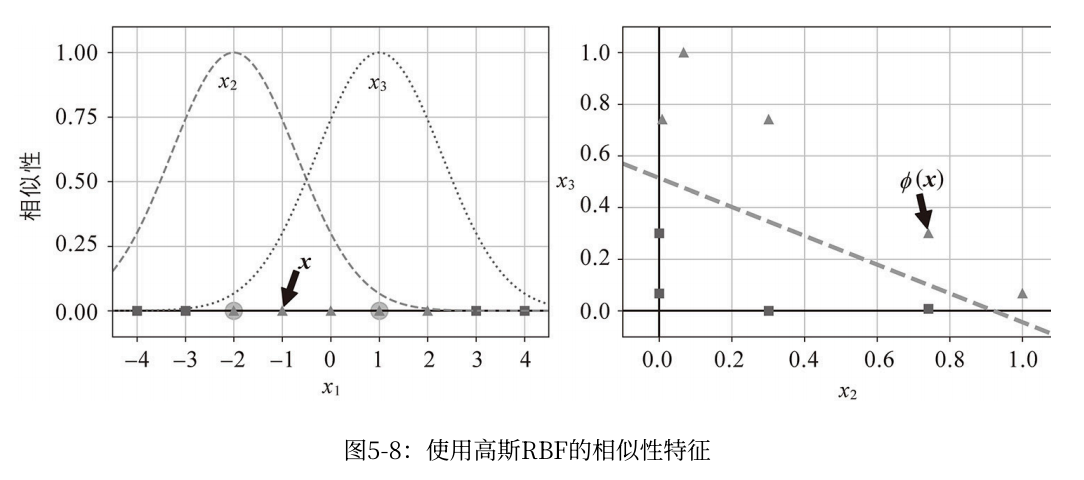
*   在原始的一维空间里，两类数据可能交错在一起。
*   **投影后：** 经过 RBF 转换，数据点分布在了新的二维空间里。此时，你只需要画一条简单的**直线（线性决策边界）**，就能把原本复杂的两类数据完美分开。

---

### 4. 这种方法的“代价”是什么？
虽然这种方法很强大，但它有一个明显的缺点：**特征爆炸**。
*   **如何选地标？** 文中提到最简单的办法是在**每一个**训练实例的位置都设一个地标。
*   **后果：** 如果你有 1000 个样本，转换后每个样本就会拥有 1000 个特征，每个样本都要计算它与这1000个地标的相似度。（这是一种简单但是极端的方案）
    *   **优点：** 维度越高，数据越容易被分开。
    *   **缺点：** 计算量剧增，如果训练集非常大，内存和计算资源可能会吃不消。

**总结：**
这套逻辑本质上是利用 **距离（相似性）** 将数据重新编码。它把难搞的非线性问题，转化成了高维空间里简单的线性问题。这也是著名的“核技巧”（Kernel Trick）背后的直观思路。

---

### 5. 如何设置2个地标将1000一维个样本映射到二维空间（使其线性可分），同时保持其公平性？

### 1. 放置在不同类别的“中心”附近
为了让两类数据在新的维度上拉开距离，最公平且有效的办法是将地标分别放置在两个类别的核心区域：
*   **逻辑：** 地标 A 放在类 A 的聚集处，地标 B 放在类 B 的聚集处。
*   **结果：** 这样类 A 的样本在特征 $x_2$（与地标 A 的相似度）上得分高，在 $x_3$（与地标 B 的相似度）上得分低；类 B 则相反。这种“对立”关系最容易在二维平面上形成线性分割。

### 2. 参考数据分布的边界（Landmark Selection）
如果不按类别中心放，也可以参考数据的分界点：
*   **逻辑：** 观察原始一维数据在哪里交错，将地标放置在**交错区域的两侧**。
*   **公平性：** 这种方式不偏袒任何一个特定样本，而是通过捕捉数据的整体分布形态（即 RBF 的钟形曲线覆盖范围）来重新编码位置信息。

### 3. 随机选择（Random Selection）
*   **逻辑：** 从 1000 个样本中随机挑选 2 个样本点作为地标。
*   **评价：** 这在计算上最省力，虽然有一定的随机性，但在样本量大时，随机挑选往往也能覆盖到具有代表性的位置。

### 4. 使用聚类算法（如 K-Means）
这是最科学的“公平”设置方法：
*   **逻辑：** 先对 1000 个样本进行 K-Means 聚类，聚成 2 类，然后将这两个类的**质心（Centroids）**作为地标。
*   **优点：** 质心代表了数据的数学统计中心，能最大程度地代表样本的整体特征。

**核心总结：**
设置地标的本质是**选参照物**。为了让 2 个地标就能实现线性可分，你需要确保这两个参照物能**区分出数据的差异性**。如果两个地标靠得太近，计算出的两个新特征会高度相关，数据在二维空间里依然会挤成一团，无法被直线分开。

#### 下面介绍高斯RBF核

In [112]:
rbf_kernel_svm_clf = make_pipeline(
    StandardScaler(),
    SVC(kernel="rbf",gamma=5,C=0.001)
)
rbf_kernel_svm_clf.fit(X_train, y_train)

# 查看 ACC 与 F1
y_pred_rbf = rbf_kernel_svm_clf.predict(X_test)
print("\n--- 高斯 RBF 核评估结果 ---")
print(f"准确率 (ACC): {accuracy_score(y_test, y_pred_rbf):.4f}")
print(f"F1 分数: {f1_score(y_test, y_pred_rbf):.4f}")


--- 高斯 RBF 核评估结果 ---
准确率 (ACC): 0.6333
F1 分数: 0.0000


### 一、核心逻辑与“核技巧”

*   **核技巧（Kernel Trick）的魔力**：相似性特征方法如果真的去计算每一个新特征，计算成本会巨大。SVM通过“核技巧”可以在不实际添加这些特征的情况下，达到同样的分类效果。
*   **对决策边界的影响**：
    *   **$\gamma$ 变大**：决策边界会变得更不规则，甚至开始围着单个实例“绕弯”（变得非常敏感）。
    *   **$\gamma$ 变小**：钟形曲线变宽，样本影响范围变大，决策边界会变得更加平坦、平滑。
*   **正则化作用**：$\gamma$ 就像一个正则化参数。如果模型**过拟合**，应该减小 $\gamma$；如果模型**欠拟合**，则应增大 $\gamma$。

#### 1. 什么是“影响范围”变小了？

在RBF核中，$\gamma$ 参数控制着高斯钟形曲线的“胖瘦”。

*   **从数学上看：** $\gamma$ 越大，指数函数 $e^{-\gamma \|x-\ell\|^2}$ 随距离增加而衰减的速度就越快。
*   **从物理直觉看：**
    *   **低 $\gamma$（大影响范围）：** 每个样本点像一盏大功率探照灯(钟形曲线即为射出的光束)，光照范围极广。即便离它很远的地方，依然能感受到它的“亮光”（即相似性得分）。
    *   **高 $\gamma$（小影响范围）：** 每个样本点像一根小蜡烛，只有贴近它时才有光，稍远一点就完全陷入黑暗（即相似性得分迅速降为 0）。

#### 2. 为什么导致决策边界变得“不规则”？

当 **$\gamma$ 很大**（影响范围很小）时：
*   **逻辑：** 既然每盏灯只能照亮自己脚下的一小块地方，模型就无法把邻近的同类点联结成一个整体。
*   **现象：** 为了把每个被“照亮”的孤立点都圈进去，决策边界必须像一条细线一样，小心翼翼地绕过每一个点。
*   **结果：** 边界会变得非常扭曲、破碎，甚至在每个点周围形成一个个独立的“小岛”（见图5-9右下角 $\gamma=5$ 的图）。这就像是过度敏感，任何一个孤立的样本都会让边界发生剧烈抖动。

#### 3. 为什么导致决策边界变得“平坦”？

当 **$\gamma$ 很小**（影响范围很大）时：
*   **逻辑：** 所有的灯泡光圈都很大，互相重叠。在这种情况下，模型看到的不再是单个的“点”，而是一片片交织在一起的“光海”。
*   **现象：** 局部微小的样本差异会被这种大范围的影响力给“抹平”。模型不再关注某个特定点的微小波动，而是关注一大群点共同构成的趋势。
*   **结果：** 决策边界变得非常平滑、宽阔，更像是一条平缓的波浪线或直线（见图5-9左上角 $\gamma=0.1$ 的图）。这增加了模型的泛化能力，但也可能导致它对细节“视而不见”（欠拟合）。

#### 总结对比

| $\gamma$ 大小 | 影响范围 | 边界形态 | 拟合倾向 |
| :--- | :--- | :--- | :--- |
| **大 $\gamma$** | 小（窄） | **不规则、扭曲**：紧紧包裹每个点，像迷宫。 | 容易**过拟合** |
| **小 $\gamma$** | 大（宽） | **平坦、平滑**：横冲直撞，不顾小节。 | 容易**欠拟合** |

所以，调节 $\gamma$ 的本质是在 **“尊重每一个个体的特殊性”**（高 $\gamma$）与 **“追求整体分布的普遍性”**（低 $\gamma$）之间寻找平衡。

---

### 二、不同参数对拟合曲面的影响
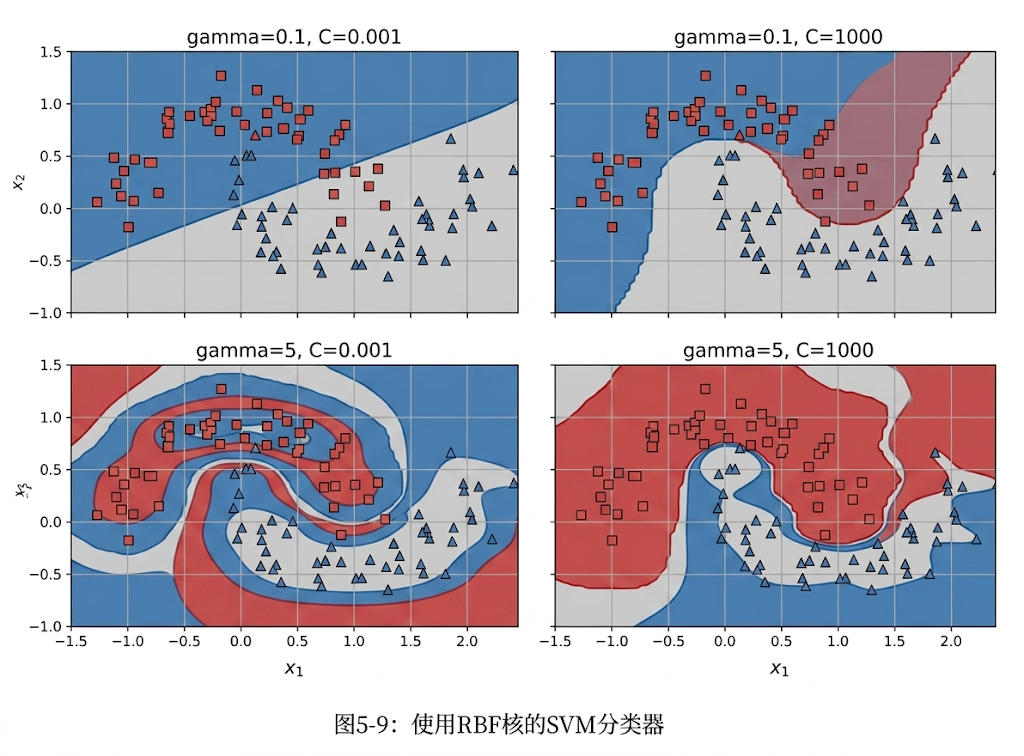

#### 1. $\gamma$ (gamma) 的影响（纵向对比）
*   **低 $\gamma$ (如 $\gamma = 0.1$)**：决策边界非常平滑、宽阔。模型倾向于看数据的“大势”，忽略局部波动。
*   **高 $\gamma$ (如 $\gamma = 5$)**：决策边界变得复杂且局部化。你可以看到在 $\gamma=5$ 的图中，边界紧紧包裹着数据点的分布形状，甚至出现了明显的“岛屿”感。

#### 2. $C$ 的影响（横向对比）
*   **小 $C$ (如 $C = 0.001$)**：这是一个**强正则化**的状态。模型非常容忍违规点（分类错误的点），为了保持边界的简单（平滑），它宁愿错分一些样本。此时边界受单个点的影响很小。
*   **大 $C$ (如 $C = 1000$)**：这是一个**弱正则化**的状态。模型会尽量正确分类每一个样本。为了迁就某些离群点，边界会发生剧烈的扭曲。

#### 3. 组合效果总结
| 组合方案 | 拟合特征 | 风险 |
| :--- | :--- | :--- |
| **小 $\gamma$, 小 $C$** | 决策边界几乎是一条直线/平滑曲线。 | 容易**欠拟合**，无法捕捉复杂结构。 |
| **小 $\gamma$, 大 $C$** | 边界依然相对平滑，但会为了减少错误而做出更大的弯曲补偿。 | 较平衡，但可能在边缘处敏感。 |
| **大 $\gamma$, 小 $C$** | 边界虽然局部化，但受 $C$ 的限制，不会过于极端地追逐每个点。 | 产生模糊的局部区域。 |
| **大 $\gamma$, 大 $C$** | 边界非常复杂，紧密贴合每一个样本点的轮廓。 | 极易**过拟合**，模型失去了泛化能力。 |

**结论**：如果你发现模型在训练集上表现完美但在新数据上很差（过拟合），你应该尝试同时**减小 $\gamma$** 或 **减小 $C$**。